# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ahmedfurqan1/FlyRank-MachineLearning/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

Can March search-performance signals rank content items for human review before their impressions decline by more than 15% in April, and do Logistic Regression or Random Forest provide a meaningful improvement over a transparent fixed rule?

### Decision supported

SEO managers and content editors cannot investigate every content item during each review cycle. This capstone supports the decision of which items should be diagnosed first when review capacity is limited to 50 recommendations.

One analysis unit is one pseudonymized client-content pair per monthly window. March 2026 supplies the development features, while April 2026 supplies the observed outcome. The primary metric is Precision@50, and Precision@20 is a secondary capacity check.

A false positive wastes editorial time and could lead to unnecessary changes. A false negative leaves a potentially important decline outside the review queue. The ranking therefore supports human diagnosis rather than automatic editing, refreshing, publishing, deletion, redirecting, or pruning.

Scores represent relative ranking priority, not recovery probabilities. The analysis measures associations in observed search performance and does not establish why impressions changed or whether a content update would cause recovery.

May features and June outcomes are reserved for a one-time later-period evaluation of the three frozen methods. June remains sealed until the evaluation protocol and scoring code have been verified.

In [ ]:
import pandas as pd
from IPython.display import display

DEVELOPMENT_FEATURE_MONTH = "2026-03"
DEVELOPMENT_OUTCOME_MONTH = "2026-04"
SEALED_FEATURE_MONTH = "2026-05"
SEALED_OUTCOME_MONTH = "2026-06"
DECLINE_THRESHOLD_FRACTION = -0.15
PRIMARY_K_COUNT = 50
SECONDARY_K_COUNT = 20
RANDOM_SEED = 42
SEALED_PERIOD_IS_LOADED = False

study_design = pd.DataFrame(
    [
        ("lane", "Refresh / Content Opportunity Scoring"),
        ("analysis_type", "classification used for ranking"),
        ("unit_of_analysis", "one pseudonymized client-content pair per monthly window"),
        ("development_feature_month", DEVELOPMENT_FEATURE_MONTH),
        ("development_outcome_month", DEVELOPMENT_OUTCOME_MONTH),
        ("sealed_feature_month", SEALED_FEATURE_MONTH),
        ("sealed_outcome_month", SEALED_OUTCOME_MONTH),
        ("outcome_label", "outcome impressions more than 15% below feature-month impressions"),
        ("primary_metric", f"Precision@{PRIMARY_K_COUNT}"),
        ("secondary_metric", f"Precision@{SECONDARY_K_COUNT}"),
        ("development_validation", "five-fold GroupKFold by client"),
        ("locked_methods", "fixed baseline, Logistic Regression, Random Forest"),
        ("development_selected_method", "fixed baseline"),
        ("decision_scope", "human diagnosis and review prioritization"),
        ("sealed_period_is_loaded", SEALED_PERIOD_IS_LOADED),
    ],
    columns=["design_field", "locked_value"],
)

assert DECLINE_THRESHOLD_FRACTION == -0.15
assert PRIMARY_K_COUNT == 50
assert SECONDARY_K_COUNT == 20
assert RANDOM_SEED == 42
assert SEALED_PERIOD_IS_LOADED is False

display(study_design)

,design_field,locked_value
0,lane,Refresh / Content Opportunity Scoring
1,analysis_type,classification used for ranking
2,unit_of_analysis,one pseudonymized client-content pair per mont...
3,development_feature_month,2026-03
4,development_outcome_month,2026-04
5,sealed_feature_month,2026-05
6,sealed_outcome_month,2026-06
7,outcome_label,outcome impressions more than 15% below featur...
8,primary_metric,Precision@50
9,secondary_metric,Precision@20


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Release and source

This analysis uses build `flyrank_pseudonymized_warehouse_release_v20260703` of the FlyRank internship warehouse. It reads the full `fact_content_daily_performance` table for March and April 2026.

The source table contains one daily observation per pseudonymized client-content pair. Daily rows are aggregated so that one modeling row represents one client-content pair across a monthly feature window and its following monthly outcome window.

### Windows and measurements

March 2026 is the development feature window. March impressions and clicks are summed, average search position is weighted by impressions, and CTR is calculated as clicks divided by impressions on the percentage scale.

April 2026 is used only to construct the observed outcome. The label equals 1 when April impressions are more than 15% below March impressions and 0 otherwise. Development evaluation includes pairs with positive March impressions and a matched April observation.

May and June are not loaded in this section. They remain reserved for the frozen later-period evaluation.

### Exclusions and privacy

Pseudonymized identifiers are retained internally only for joining, deterministic ordering, and client-grouped validation. They are never model features or public outputs.

April measurements, the outcome label, trend-derived fields, product-generated scores and flags, and sealed-period fields are excluded from scoring features. The query-level table is excluded because its fixed window overlaps recent outcome periods and its details are not needed for this analysis.

GA4 fields are also excluded from the locked model because availability is sparse and the final feature set uses decision-time search measurements only. All displayed outputs are aggregate and public-safe.

In [ ]:
import getpass
import duckdb
import numpy as np
import pandas as pd
from IPython.display import display

assert DEVELOPMENT_FEATURE_MONTH == "2026-03"
assert DEVELOPMENT_OUTCOME_MONTH == "2026-04"
assert SEALED_PERIOD_IS_LOADED is False

DECLINE_OUTCOME_MULTIPLIER = 1 + DECLINE_THRESHOLD_FRACTION
LOADED_MONTHS = (
    DEVELOPMENT_FEATURE_MONTH,
    DEVELOPMENT_OUTCOME_MONTH,
)

assert SEALED_FEATURE_MONTH not in LOADED_MONTHS
assert SEALED_OUTCOME_MONTH not in LOADED_MONTHS

try:
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
except Exception:
    hf_token = None

if not hf_token:
    hf_token = getpass.getpass("Enter your Hugging Face READ token: ")

if not hf_token or not hf_token.startswith("hf_"):
    raise ValueError("A valid Hugging Face READ token is required.")

connection = duckdb.connect()
safe_token = hf_token.replace("'", "''")

connection.execute(
    f"""
    CREATE OR REPLACE SECRET flyrank_hf (
        TYPE huggingface,
        TOKEN '{safe_token}'
    )
    """
)

del hf_token, safe_token

WAREHOUSE_ROOT = "hf://datasets/FlyRank/internship-warehouse"
MARCH_FACT_PATH = (
    f"{WAREHOUSE_ROOT}/fact_content_daily_performance/"
    "month=2026-03/*.parquet"
)
APRIL_FACT_PATH = (
    f"{WAREHOUSE_ROOT}/fact_content_daily_performance/"
    "month=2026-04/*.parquet"
)

analysis_df = connection.execute(
    f"""
    WITH march AS (
        SELECT
            client_hash_id,
            content_hash_id,
            COUNT(DISTINCT report_date) AS march_observed_day_count,
            SUM(gsc_impressions) AS march_impressions_count,
            SUM(gsc_clicks) AS march_clicks_count,
            SUM(gsc_sum_position)
                / NULLIF(SUM(gsc_impressions), 0)
                AS march_avg_search_position
        FROM read_parquet('{MARCH_FACT_PATH}')
        WHERE gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
    ),
    april AS (
        SELECT
            client_hash_id,
            content_hash_id,
            COUNT(DISTINCT report_date) AS april_observed_day_count,
            SUM(gsc_impressions) AS april_impressions_count
        FROM read_parquet('{APRIL_FACT_PATH}')
        WHERE gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
    )
    SELECT
        march.client_hash_id,
        march.content_hash_id,
        march.march_observed_day_count,
        march.march_impressions_count,
        march.march_clicks_count,
        march.march_avg_search_position,
        100.0 * march.march_clicks_count
            / NULLIF(march.march_impressions_count, 0)
            AS march_ctr_pct,
        april.april_observed_day_count,
        april.april_impressions_count,
        CASE
            WHEN april.april_impressions_count
                < {DECLINE_OUTCOME_MULTIPLIER}
                * march.march_impressions_count
            THEN 1
            ELSE 0
        END AS is_declining_label
    FROM march
    INNER JOIN april
        USING (client_hash_id, content_hash_id)
    WHERE march.march_impressions_count > 0
    """
).df()

connection.close()

analysis_df = (
    analysis_df
    .sort_values(["client_hash_id", "content_hash_id"])
    .reset_index(drop=True)
)

analysis_row_count = len(analysis_df)
client_count = analysis_df["client_hash_id"].nunique()
duplicate_unit_count = analysis_df.duplicated(
    ["client_hash_id", "content_hash_id"]
).sum()
decline_base_rate_pct = round(
    100 * analysis_df["is_declining_label"].mean(),
    1,
)

assert duplicate_unit_count == 0
assert analysis_df["march_impressions_count"].gt(0).all()
assert analysis_df["is_declining_label"].isin([0, 1]).all()
assert analysis_df[
    [
        "march_impressions_count",
        "march_clicks_count",
        "march_avg_search_position",
        "march_ctr_pct",
        "april_impressions_count",
        "is_declining_label",
    ]
].notna().all().all()

data_audit = pd.DataFrame(
    [
        ("release_build", "flyrank_pseudonymized_warehouse_release_v20260703"),
        ("source_table", "fact_content_daily_performance"),
        ("source_grain", "one daily client-content observation"),
        ("modeling_grain", "one client-content pair across two monthly windows"),
        ("loaded_months", ", ".join(LOADED_MONTHS)),
        ("analysis_row_count", analysis_row_count),
        ("client_count", client_count),
        ("duplicate_unit_count", duplicate_unit_count),
        ("decline_base_rate_pct", decline_base_rate_pct),
        (
            "minimum_march_observed_day_count",
            int(analysis_df["march_observed_day_count"].min()),
        ),
        (
            "median_march_observed_day_count",
            float(analysis_df["march_observed_day_count"].median()),
        ),
        (
            "maximum_march_observed_day_count",
            int(analysis_df["march_observed_day_count"].max()),
        ),
        ("sealed_period_is_loaded", SEALED_PERIOD_IS_LOADED),
    ],
    columns=["audit_field", "observed_value"],
)

display(data_audit)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,audit_field,observed_value
0,release_build,flyrank_pseudonymized_warehouse_release_v20260703
1,source_table,fact_content_daily_performance
2,source_grain,one daily client-content observation
3,modeling_grain,one client-content pair across two monthly win...
4,loaded_months,"2026-03, 2026-04"
5,analysis_row_count,158549
6,client_count,46
7,duplicate_unit_count,0
8,decline_base_rate_pct,51.1
9,minimum_march_observed_day_count,1


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Outcome and ranking task

The binary outcome equals 1 when April impressions are more than 15% below March impressions. Classification methods produce scores used only to rank content for review. The scores are not treated as calibrated probabilities.

### Fixed baseline

The fixed baseline selects a content item when all three conditions are met:

1. March impressions are at least 100.
2. March clicks equal zero.
3. March average search position is greater than 0 and no worse than 20.

Eligible items are ranked by March impressions. The rule prioritizes affected exposure and remains interpretable, but it does not diagnose why clicks or impressions changed.

### Model features

Logistic Regression and Random Forest use the same six March-only features:

- log-transformed March impressions;
- log-transformed March clicks;
- March average search position;
- March CTR;
- a zero-click indicator;
- the baseline-eligibility indicator.

The eligibility indicator is derived from the transparent decision rule rather than a product score. Its contribution is checked separately in the validation audit.

Logistic Regression uses median imputation, standardization, and a maximum of 2,000 iterations. Random Forest uses median imputation, 150 trees, maximum depth 8, minimum leaf size 50, square-root feature sampling, and seed 42.

### Validation design

Five-fold GroupKFold validation keeps every client entirely within one fold. For each fold, models train on four client groups and rank rows from the held-out group. The baseline and both models are evaluated on identical validation rows using Precision@50 and Precision@20.

Content identifiers are used only to make tied rankings deterministic. Mean precision and fold variation are reported because performance differs across client groups.

### Leakage protection

Identifiers, April measurements, the outcome label, trend-derived fields, product-generated flags and scores, baseline ranking values, and sealed-period fields are excluded from model features. All permitted features are available by the end of March.

The later May-to-June test will use these same transformations, models, settings, metrics, and ranking rules. June will be loaded only after the temporal evaluation code is frozen.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

GROUP_FOLD_COUNT = 5
BASELINE_MINIMUM_IMPRESSIONS_COUNT = 100
BASELINE_MAXIMUM_AVG_SEARCH_POSITION = 20

MODEL_FEATURE_COLUMNS = [
    "log1p_march_impressions_count",
    "log1p_march_clicks_count",
    "march_avg_search_position",
    "march_ctr_pct",
    "is_zero_click",
    "is_baseline_eligible",
]

FORBIDDEN_FEATURE_COLUMNS = {
    "client_hash_id",
    "content_hash_id",
    "april_observed_day_count",
    "april_impressions_count",
    "is_declining_label",
    "baseline_priority_impressions_count",
    "trend_direction",
    "trend_pct",
    "health_score",
    "needs_ctr_fix",
    "is_quick_win",
}

analysis_df["log1p_march_impressions_count"] = np.log1p(
    analysis_df["march_impressions_count"]
)
analysis_df["log1p_march_clicks_count"] = np.log1p(
    analysis_df["march_clicks_count"]
)
analysis_df["is_zero_click"] = analysis_df[
    "march_clicks_count"
].eq(0)
analysis_df["is_baseline_eligible"] = (
    analysis_df["march_impressions_count"].ge(
        BASELINE_MINIMUM_IMPRESSIONS_COUNT
    )
    & analysis_df["is_zero_click"]
    & analysis_df["march_avg_search_position"].gt(0)
    & analysis_df["march_avg_search_position"].le(
        BASELINE_MAXIMUM_AVG_SEARCH_POSITION
    )
)
analysis_df["baseline_priority_impressions_count"] = np.where(
    analysis_df["is_baseline_eligible"],
    analysis_df["march_impressions_count"],
    0,
)

analysis_df[MODEL_FEATURE_COLUMNS] = analysis_df[
    MODEL_FEATURE_COLUMNS
].replace([np.inf, -np.inf], np.nan)

assert set(MODEL_FEATURE_COLUMNS).issubset(analysis_df.columns)
assert set(MODEL_FEATURE_COLUMNS).isdisjoint(
    FORBIDDEN_FEATURE_COLUMNS
)
assert analysis_df[MODEL_FEATURE_COLUMNS].notna().all().all()
assert SEALED_PERIOD_IS_LOADED is False
assert SEALED_FEATURE_MONTH not in LOADED_MONTHS
assert SEALED_OUTCOME_MONTH not in LOADED_MONTHS

expected_march_ctr_pct = (
    100
    * analysis_df["march_clicks_count"]
    / analysis_df["march_impressions_count"]
)
expected_is_zero_click = analysis_df[
    "march_clicks_count"
].eq(0)
expected_is_baseline_eligible = (
    analysis_df["march_impressions_count"].ge(
        BASELINE_MINIMUM_IMPRESSIONS_COUNT
    )
    & expected_is_zero_click
    & analysis_df["march_avg_search_position"].gt(0)
    & analysis_df["march_avg_search_position"].le(
        BASELINE_MAXIMUM_AVG_SEARCH_POSITION
    )
)

assert np.allclose(
    analysis_df["march_ctr_pct"],
    expected_march_ctr_pct,
)
assert analysis_df["is_zero_click"].equals(
    expected_is_zero_click
)
assert analysis_df["is_baseline_eligible"].equals(
    expected_is_baseline_eligible
)

grouped_splitter = GroupKFold(n_splits=GROUP_FOLD_COUNT)
analysis_df["grouped_validation_fold"] = -1

for fold_number, (_, validation_index) in enumerate(
    grouped_splitter.split(
        X=np.zeros(len(analysis_df)),
        y=analysis_df["is_declining_label"],
        groups=analysis_df["client_hash_id"],
    ),
    start=1,
):
    analysis_df.loc[
        analysis_df.iloc[validation_index].index,
        "grouped_validation_fold",
    ] = fold_number

assert analysis_df["grouped_validation_fold"].between(
    1,
    GROUP_FOLD_COUNT,
).all()

client_fold_count = (
    analysis_df
    .groupby("client_hash_id")["grouped_validation_fold"]
    .nunique()
)

assert client_fold_count.eq(1).all()

client_overlap_count = 0

for fold_number in range(1, GROUP_FOLD_COUNT + 1):
    training_client_ids = set(
        analysis_df.loc[
            analysis_df["grouped_validation_fold"].ne(fold_number),
            "client_hash_id",
        ]
    )
    validation_client_ids = set(
        analysis_df.loc[
            analysis_df["grouped_validation_fold"].eq(fold_number),
            "client_hash_id",
        ]
    )
    fold_client_overlap_count = len(
        training_client_ids.intersection(validation_client_ids)
    )
    client_overlap_count += fold_client_overlap_count

assert client_overlap_count == 0

estimators = {
    "Logistic Regression": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=150,
                    max_depth=8,
                    min_samples_leaf=50,
                    max_features="sqrt",
                    n_jobs=-1,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    ),
}

feature_audit = pd.DataFrame(
    [
        (
            "log1p_march_impressions_count",
            "March 2026",
            False,
            "allowed",
        ),
        (
            "log1p_march_clicks_count",
            "March 2026",
            False,
            "allowed",
        ),
        (
            "march_avg_search_position",
            "March 2026",
            False,
            "allowed",
        ),
        (
            "march_ctr_pct",
            "March 2026",
            False,
            "allowed",
        ),
        (
            "is_zero_click",
            "March 2026",
            False,
            "allowed",
        ),
        (
            "is_baseline_eligible",
            "March 2026",
            True,
            "sensitivity check required",
        ),
    ],
    columns=[
        "feature",
        "source_window",
        "is_decision_rule_derived",
        "audit_verdict",
    ],
)

grouped_fold_audit = (
    analysis_df
    .groupby("grouped_validation_fold")
    .agg(
        validation_row_count=("content_hash_id", "size"),
        validation_client_count=("client_hash_id", "nunique"),
        decline_base_rate_fraction=("is_declining_label", "mean"),
    )
    .reset_index()
)

grouped_fold_audit["decline_base_rate_pct"] = (
    100 * grouped_fold_audit["decline_base_rate_fraction"]
).round(1)

grouped_fold_audit = grouped_fold_audit[
    [
        "grouped_validation_fold",
        "validation_row_count",
        "validation_client_count",
        "decline_base_rate_pct",
    ]
]

baseline_eligible_count = int(
    analysis_df["is_baseline_eligible"].sum()
)

method_audit = pd.DataFrame(
    [
        ("model_feature_count", len(MODEL_FEATURE_COLUMNS)),
        ("group_fold_count", GROUP_FOLD_COUNT),
        ("baseline_eligible_count", baseline_eligible_count),
        ("client_overlap_count", client_overlap_count),
        (
            "missing_model_feature_value_count",
            int(analysis_df[MODEL_FEATURE_COLUMNS].isna().sum().sum()),
        ),
        (
            "forbidden_feature_overlap_count",
            len(
                set(MODEL_FEATURE_COLUMNS).intersection(
                    FORBIDDEN_FEATURE_COLUMNS
                )
            ),
        ),
        ("sealed_period_is_loaded", SEALED_PERIOD_IS_LOADED),
    ],
    columns=["audit_field", "observed_value"],
)

display(feature_audit)
display(grouped_fold_audit)
display(method_audit)

,feature,source_window,is_decision_rule_derived,audit_verdict
0,log1p_march_impressions_count,March 2026,False,allowed
1,log1p_march_clicks_count,March 2026,False,allowed
2,march_avg_search_position,March 2026,False,allowed
3,march_ctr_pct,March 2026,False,allowed
4,is_zero_click,March 2026,False,allowed
5,is_baseline_eligible,March 2026,True,sensitivity check required


,grouped_validation_fold,validation_row_count,validation_client_count,decline_base_rate_pct
0,1,31712,8,46.3
1,2,31708,8,67.8
2,3,31707,10,35.6
3,4,31706,11,54.4
4,5,31716,9,51.3


,audit_field,observed_value
0,model_feature_count,6
1,group_fold_count,5
2,baseline_eligible_count,23716
3,client_overlap_count,0
4,missing_model_feature_value_count,0
5,forbidden_feature_overlap_count,0
6,sealed_period_is_loaded,False


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Client-grouped development comparison

The fixed baseline, Logistic Regression, and Random Forest are evaluated on the same five held-out client groups. Each model is trained using four folds and scores the remaining fold.

Precision@50 is the primary metric, while Precision@20 measures performance at a smaller review capacity. The outcome base rate provides the reference level for interpreting ranking enrichment.

The table reports mean precision and standard deviation across folds. Fold variation is retained because one average can hide differences between client groups.

,validation_fold,decline_base_rate_pct,baseline_p20_pct,baseline_p50_pct,logistic_p20_pct,logistic_p50_pct,forest_p20_pct,forest_p50_pct
0,1,46.3,65.0,56.0,65.0,58.0,65.0,66.0
1,2,67.8,80.0,84.0,80.0,84.0,85.0,84.0
2,3,35.6,70.0,60.0,75.0,68.0,50.0,54.0
3,4,54.4,95.0,78.0,75.0,80.0,40.0,56.0
4,5,51.3,65.0,66.0,65.0,56.0,70.0,68.0


,method,outcome_base_rate_pct,mean_p20_pct,p20_std_pp,mean_p50_pct,p50_std_pp
0,Fixed baseline,51.1,75.0,12.7,68.8,11.9
1,Logistic Regression,51.1,72.0,6.7,69.2,12.6
2,Random Forest,51.1,62.0,17.5,65.6,11.9


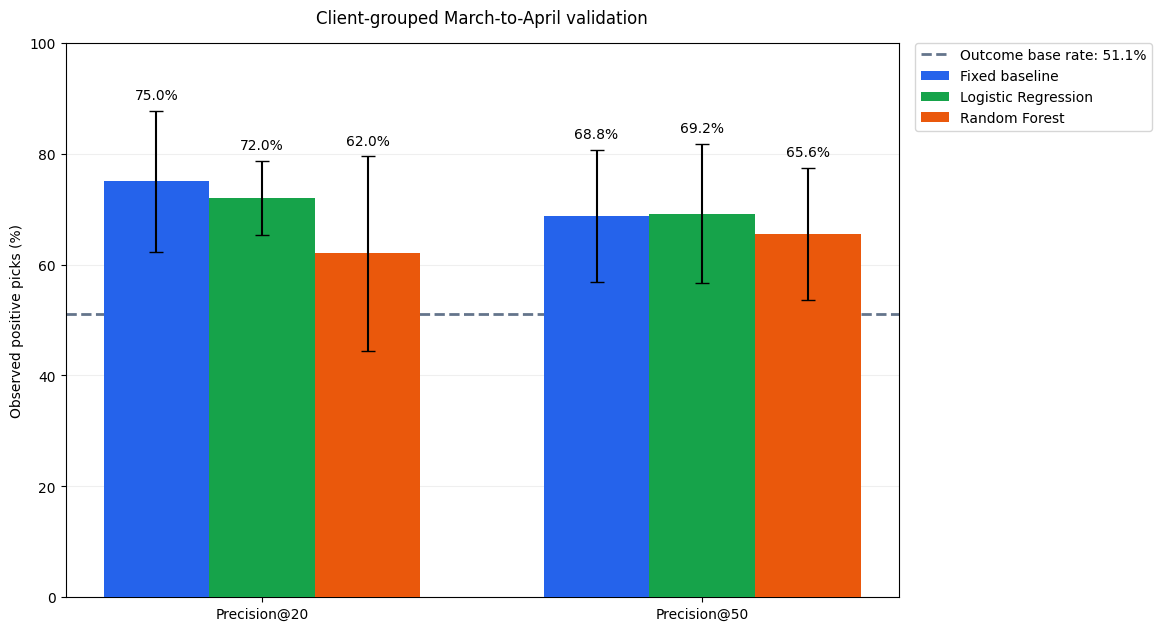

In [ ]:
from sklearn.base import clone
import matplotlib.pyplot as plt

MODEL_SCORE_COLUMN_BY_METHOD = {
    "Logistic Regression": "logistic_ranking_score_0_1",
    "Random Forest": "forest_ranking_score_0_1",
}

def precision_at_k(frame, ranking_column, k_count):
    ranked_frame = frame.sort_values(
        [ranking_column, "content_hash_id"],
        ascending=[False, True],
        kind="mergesort",
    )
    return ranked_frame.head(k_count)[
        "is_declining_label"
    ].mean()

fold_metric_rows = []
oof_prediction_frames = []

for fold_number in range(1, GROUP_FOLD_COUNT + 1):
    training_mask = analysis_df[
        "grouped_validation_fold"
    ].ne(fold_number)
    validation_mask = analysis_df[
        "grouped_validation_fold"
    ].eq(fold_number)

    X_train = analysis_df.loc[
        training_mask,
        MODEL_FEATURE_COLUMNS,
    ]
    y_train = analysis_df.loc[
        training_mask,
        "is_declining_label",
    ]
    X_validation = analysis_df.loc[
        validation_mask,
        MODEL_FEATURE_COLUMNS,
    ]

    validation_frame = analysis_df.loc[
        validation_mask,
        [
            "client_hash_id",
            "content_hash_id",
            "march_observed_day_count",
            "march_impressions_count",
            "march_clicks_count",
            "march_avg_search_position",
            "march_ctr_pct",
            "april_observed_day_count",
            "april_impressions_count",
            "is_declining_label",
            "is_baseline_eligible",
            "baseline_priority_impressions_count",
        ],
    ].copy()

    assert len(validation_frame) >= PRIMARY_K_COUNT
    assert (
        validation_frame["is_baseline_eligible"].sum()
        >= PRIMARY_K_COUNT
    )

    for method_name, estimator in estimators.items():
        fitted_estimator = clone(estimator)
        fitted_estimator.fit(X_train, y_train)

        score_column = MODEL_SCORE_COLUMN_BY_METHOD[
            method_name
        ]
        validation_frame[score_column] = (
            fitted_estimator.predict_proba(
                X_validation
            )[:, 1]
        )

    validation_frame["validation_fold"] = fold_number
    oof_prediction_frames.append(validation_frame)

    metric_row = {
        "validation_fold": fold_number,
        "decline_base_rate_pct": round(
            100
            * validation_frame[
                "is_declining_label"
            ].mean(),
            1,
        ),
    }

    for metric_prefix, ranking_column in [
        (
            "baseline",
            "baseline_priority_impressions_count",
        ),
        (
            "logistic",
            "logistic_ranking_score_0_1",
        ),
        (
            "forest",
            "forest_ranking_score_0_1",
        ),
    ]:
        metric_row[f"{metric_prefix}_p20_pct"] = round(
            100
            * precision_at_k(
                validation_frame,
                ranking_column,
                SECONDARY_K_COUNT,
            ),
            1,
        )
        metric_row[f"{metric_prefix}_p50_pct"] = round(
            100
            * precision_at_k(
                validation_frame,
                ranking_column,
                PRIMARY_K_COUNT,
            ),
            1,
        )

    fold_metric_rows.append(metric_row)

fold_metrics = pd.DataFrame(fold_metric_rows)

oof_predictions = pd.concat(
    oof_prediction_frames,
    ignore_index=True,
)

assert len(oof_predictions) == len(analysis_df)
assert oof_predictions[
    [
        "logistic_ranking_score_0_1",
        "forest_ranking_score_0_1",
    ]
].notna().all().all()

comparison_rows = []

for method_name, metric_prefix in [
    ("Fixed baseline", "baseline"),
    ("Logistic Regression", "logistic"),
    ("Random Forest", "forest"),
]:
    comparison_rows.append(
        {
            "method": method_name,
            "outcome_base_rate_pct": round(
                100
                * analysis_df[
                    "is_declining_label"
                ].mean(),
                1,
            ),
            "mean_p20_pct": round(
                fold_metrics[
                    f"{metric_prefix}_p20_pct"
                ].mean(),
                1,
            ),
            "p20_std_pp": round(
                fold_metrics[
                    f"{metric_prefix}_p20_pct"
                ].std(),
                1,
            ),
            "mean_p50_pct": round(
                fold_metrics[
                    f"{metric_prefix}_p50_pct"
                ].mean(),
                1,
            ),
            "p50_std_pp": round(
                fold_metrics[
                    f"{metric_prefix}_p50_pct"
                ].std(),
                1,
            ),
        }
    )

grouped_validation_results = pd.DataFrame(
    comparison_rows
)

expected_grouped_metrics = {
    "Fixed baseline": (75.0, 68.8),
    "Logistic Regression": (72.0, 69.2),
    "Random Forest": (62.0, 65.6),
}

for method_name, expected_values in (
    expected_grouped_metrics.items()
):
    observed_row = grouped_validation_results.loc[
        grouped_validation_results["method"].eq(
            method_name
        )
    ].iloc[0]

    assert np.isclose(
        observed_row["mean_p20_pct"],
        expected_values[0],
    )
    assert np.isclose(
        observed_row["mean_p50_pct"],
        expected_values[1],
    )

display(fold_metrics)
display(grouped_validation_results)

metric_labels = ["Precision@20", "Precision@50"]
x_positions = np.arange(len(metric_labels))
bar_width_fraction = 0.24

figure, axis = plt.subplots(
    figsize=(11.5, 6.2),
    constrained_layout=True,
)

method_colors = {
    "Fixed baseline": "#2563EB",
    "Logistic Regression": "#16A34A",
    "Random Forest": "#EA580C",
}

for method_index, method_name in enumerate(
    method_colors
):
    method_row = grouped_validation_results.loc[
        grouped_validation_results["method"].eq(
            method_name
        )
    ].iloc[0]

    mean_values_pct = np.array(
        [
            method_row["mean_p20_pct"],
            method_row["mean_p50_pct"],
        ]
    )
    std_values_pp = np.array(
        [
            method_row["p20_std_pp"],
            method_row["p50_std_pp"],
        ]
    )

    bar_positions = (
        x_positions
        + (method_index - 1) * bar_width_fraction
    )

    axis.bar(
        bar_positions,
        mean_values_pct,
        bar_width_fraction,
        yerr=std_values_pp,
        capsize=5,
        label=method_name,
        color=method_colors[method_name],
        error_kw={"linewidth": 1.5},
        zorder=3,
    )

    for bar_position, mean_pct, std_pp in zip(
        bar_positions,
        mean_values_pct,
        std_values_pp,
    ):
        axis.text(
            bar_position,
            mean_pct + std_pp + 1.5,
            f"{mean_pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
        )

outcome_base_rate_pct = grouped_validation_results[
    "outcome_base_rate_pct"
].iloc[0]

axis.axhline(
    outcome_base_rate_pct,
    color="#64748B",
    linestyle="--",
    linewidth=2,
    label=f"Outcome base rate: {outcome_base_rate_pct:.1f}%",
    zorder=2,
)

axis.set_title(
    "Client-grouped March-to-April validation",
    pad=14,
)
axis.set_ylabel("Observed positive picks (%)")
axis.set_xticks(x_positions)
axis.set_xticklabels(metric_labels)
axis.set_ylim(0, 100)
axis.grid(axis="y", alpha=0.2, zorder=1)
axis.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
)

grouped_validation_figure = figure
plt.show()

### Development results

Across five client-grouped folds, the fixed baseline measured 75.0% mean Precision@20 and 68.8% mean Precision@50, compared with a 51.1% outcome base rate. This represents enrichment of 23.9 percentage points at K=20 and 17.7 percentage points at K=50.

Logistic Regression measured 72.0% Precision@20 and 69.2% Precision@50. Its 0.4-percentage-point advantage over the baseline at K=50 was negligible relative to 12.6 percentage points of fold variation, and it performed 3.0 percentage points worse at K=20.

Random Forest measured 62.0% Precision@20 and 65.6% Precision@50. Its Precision@20 varied by 17.5 percentage points across folds, making it the weakest and least stable challenger at the smaller review capacity.

The fixed baseline was therefore selected from the development-period evidence. It offered nearly the same Precision@50 as Logistic Regression, stronger Precision@20, and a decision rule that reviewers can inspect directly. This is a development-period selection rather than evidence of future-period performance.

**Chart takeaway:** all three methods ranked declines above the outcome base rate, but added model complexity did not provide a stable improvement over the fixed rule.

In [ ]:
import getpass
from sklearn.base import clone

assert SEALED_PERIOD_IS_LOADED is False
assert SEALED_OUTCOME_MONTH == "2026-06"
assert DECLINE_THRESHOLD_FRACTION == -0.15
assert PRIMARY_K_COUNT == 50
assert SECONDARY_K_COUNT == 20
assert RANDOM_SEED == 42

X_development = analysis_df[
    MODEL_FEATURE_COLUMNS
]
y_development = analysis_df[
    "is_declining_label"
]

fitted_temporal_estimators = {}

for method_name, estimator in estimators.items():
    fitted_estimator = clone(estimator)
    fitted_estimator.fit(
        X_development,
        y_development,
    )
    fitted_temporal_estimators[
        method_name
    ] = fitted_estimator

try:
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
except Exception:
    hf_token = None

if not hf_token:
    hf_token = getpass.getpass(
        "Enter your Hugging Face READ token: "
    )

if not hf_token or not hf_token.startswith("hf_"):
    raise ValueError(
        "A valid Hugging Face READ token is required."
    )

connection = duckdb.connect()
safe_token = hf_token.replace("'", "''")

connection.execute(
    f"""
    CREATE OR REPLACE SECRET flyrank_hf (
        TYPE huggingface,
        TOKEN '{safe_token}'
    )
    """
)

del hf_token, safe_token

MAY_FACT_PATH = (
    f"{WAREHOUSE_ROOT}/fact_content_daily_performance/"
    "month=2026-05/*.parquet"
)

may_scoring_df = connection.execute(
    f"""
    SELECT
        client_hash_id,
        content_hash_id,
        COUNT(DISTINCT report_date)
            AS may_observed_day_count,
        SUM(gsc_impressions)
            AS may_impressions_count,
        SUM(gsc_clicks)
            AS may_clicks_count,
        SUM(gsc_sum_position)
            / NULLIF(SUM(gsc_impressions), 0)
            AS may_avg_search_position
    FROM read_parquet('{MAY_FACT_PATH}')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
    HAVING SUM(gsc_impressions) > 0
    """
).df()

connection.close()

may_scoring_df = (
    may_scoring_df
    .sort_values(
        ["client_hash_id", "content_hash_id"]
    )
    .reset_index(drop=True)
)

may_scoring_df["may_ctr_pct"] = (
    100
    * may_scoring_df["may_clicks_count"]
    / may_scoring_df["may_impressions_count"]
)
may_scoring_df["is_zero_click"] = may_scoring_df[
    "may_clicks_count"
].eq(0)
may_scoring_df["is_baseline_eligible"] = (
    may_scoring_df["may_impressions_count"].ge(
        BASELINE_MINIMUM_IMPRESSIONS_COUNT
    )
    & may_scoring_df["is_zero_click"]
    & may_scoring_df["may_avg_search_position"].gt(0)
    & may_scoring_df["may_avg_search_position"].le(
        BASELINE_MAXIMUM_AVG_SEARCH_POSITION
    )
)
may_scoring_df[
    "baseline_priority_impressions_count"
] = np.where(
    may_scoring_df["is_baseline_eligible"],
    may_scoring_df["may_impressions_count"],
    0,
)

may_model_features_df = pd.DataFrame(
    {
        "log1p_march_impressions_count": np.log1p(
            may_scoring_df[
                "may_impressions_count"
            ]
        ),
        "log1p_march_clicks_count": np.log1p(
            may_scoring_df[
                "may_clicks_count"
            ]
        ),
        "march_avg_search_position": may_scoring_df[
            "may_avg_search_position"
        ],
        "march_ctr_pct": may_scoring_df[
            "may_ctr_pct"
        ],
        "is_zero_click": may_scoring_df[
            "is_zero_click"
        ],
        "is_baseline_eligible": may_scoring_df[
            "is_baseline_eligible"
        ],
    }
)

may_model_features_df = may_model_features_df[
    MODEL_FEATURE_COLUMNS
].replace([np.inf, -np.inf], np.nan)

assert may_model_features_df.notna().all().all()

may_scoring_df[
    "logistic_ranking_score_0_1"
] = fitted_temporal_estimators[
    "Logistic Regression"
].predict_proba(
    may_model_features_df
)[:, 1]

may_scoring_df[
    "forest_ranking_score_0_1"
] = fitted_temporal_estimators[
    "Random Forest"
].predict_proba(
    may_model_features_df
)[:, 1]

frozen_temporal_scoring_df = may_scoring_df[
    [
        "client_hash_id",
        "content_hash_id",
        "may_observed_day_count",
        "may_impressions_count",
        "may_clicks_count",
        "may_avg_search_position",
        "may_ctr_pct",
        "is_zero_click",
        "is_baseline_eligible",
        "baseline_priority_impressions_count",
        "logistic_ranking_score_0_1",
        "forest_ranking_score_0_1",
    ]
].copy()

may_scoring_row_count = len(
    frozen_temporal_scoring_df
)
may_client_count = frozen_temporal_scoring_df[
    "client_hash_id"
].nunique()
may_baseline_eligible_count = int(
    frozen_temporal_scoring_df[
        "is_baseline_eligible"
    ].sum()
)

assert not frozen_temporal_scoring_df.duplicated(
    ["client_hash_id", "content_hash_id"]
).any()
assert frozen_temporal_scoring_df[
    "may_impressions_count"
].gt(0).all()
assert frozen_temporal_scoring_df[
    [
        "logistic_ranking_score_0_1",
        "forest_ranking_score_0_1",
    ]
].apply(
    lambda column: column.between(0, 1).all()
).all()
assert SEALED_PERIOD_IS_LOADED is False

temporal_freeze_audit = pd.DataFrame(
    [
        (
            "development_training_pair",
            "March features and April outcome",
        ),
        (
            "frozen_scoring_month",
            SEALED_FEATURE_MONTH,
        ),
        (
            "sealed_outcome_month",
            SEALED_OUTCOME_MONTH,
        ),
        (
            "frozen_method_count",
            3,
        ),
        (
            "frozen_methods",
            "fixed baseline, Logistic Regression, Random Forest",
        ),
        (
            "may_scoring_row_count",
            may_scoring_row_count,
        ),
        (
            "may_client_count",
            may_client_count,
        ),
        (
            "may_baseline_eligible_count",
            may_baseline_eligible_count,
        ),
        (
            "primary_k_count",
            PRIMARY_K_COUNT,
        ),
        (
            "secondary_k_count",
            SECONDARY_K_COUNT,
        ),
        (
            "decline_threshold_fraction",
            DECLINE_THRESHOLD_FRACTION,
        ),
        (
            "sealed_period_is_loaded",
            SEALED_PERIOD_IS_LOADED,
        ),
    ],
    columns=["freeze_field", "locked_value"],
)

display(temporal_freeze_audit)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,freeze_field,locked_value
0,development_training_pair,March features and April outcome
1,frozen_scoring_month,2026-05
2,sealed_outcome_month,2026-06
3,frozen_method_count,3
4,frozen_methods,"fixed baseline, Logistic Regression, Random Fo..."
5,may_scoring_row_count,237910
6,may_client_count,56
7,may_baseline_eligible_count,17834
8,primary_k_count,50
9,secondary_k_count,20


### One-time May-to-June sealed evaluation

The May scoring population, three methods, transformations, thresholds, metrics, and ranking rules were frozen before June was opened. June is now loaded once to construct the later-period outcome.

All three methods are evaluated on the same matched May-to-June rows. Logistic Regression and Random Forest remain trained only on March features and April outcomes. June information is used exclusively for evaluation and is never supplied as a feature.

This temporal evaluation is reported separately from client-grouped development validation. It measures performance in a later period, not performance on previously unseen clients.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,audit_field,observed_value
0,frozen_may_scoring_row_count,237910
1,matched_evaluation_row_count,184877
2,matched_client_count,52
3,may_to_june_match_rate_pct,77.7
4,matched_baseline_eligible_count,17432
5,june_outcome_base_rate_pct,67.2
6,minimum_june_observed_day_count,1
7,median_june_observed_day_count,26.0
8,maximum_june_observed_day_count,30
9,sealed_period_is_loaded,True


,method,outcome_base_rate_pct,p20_pct,p20_lift_vs_base_rate_pp,p50_pct,p50_lift_vs_base_rate_pp
0,Fixed baseline,67.2,75.0,7.8,84.0,16.8
1,Logistic Regression,67.2,70.0,2.8,84.0,16.8
2,Random Forest,67.2,70.0,2.8,74.0,6.8


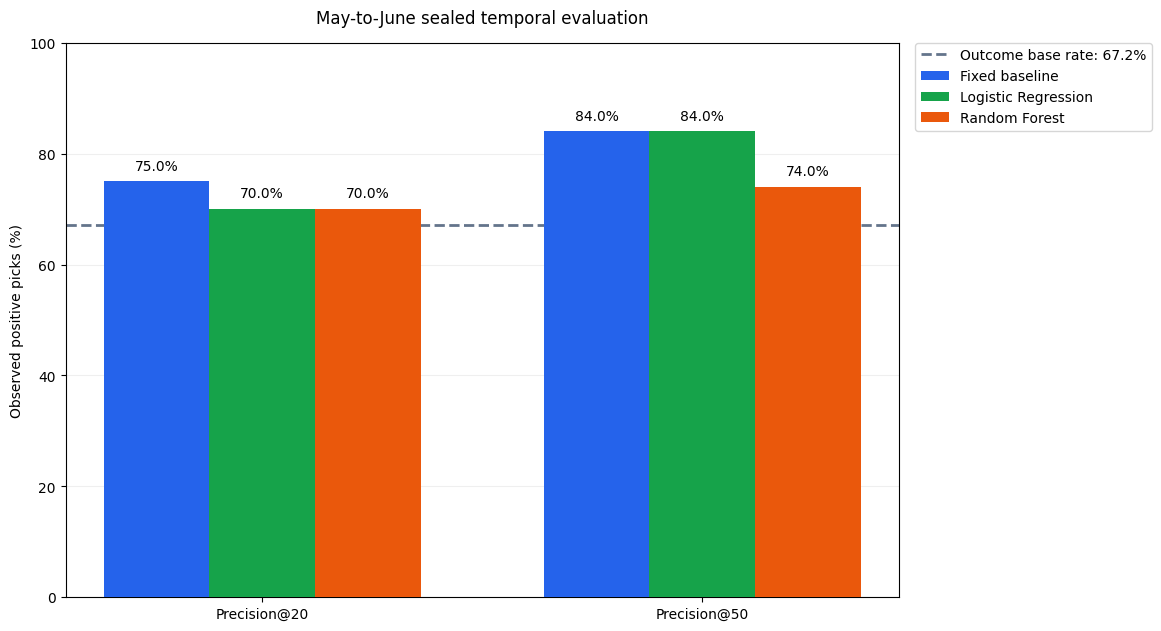

In [ ]:
import getpass
import matplotlib.pyplot as plt

assert SEALED_PERIOD_IS_LOADED is False
assert len(frozen_temporal_scoring_df) == 237910
assert PRIMARY_K_COUNT == 50
assert SECONDARY_K_COUNT == 20
assert DECLINE_THRESHOLD_FRACTION == -0.15

try:
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
except Exception:
    hf_token = None

if not hf_token:
    hf_token = getpass.getpass(
        "Enter your Hugging Face READ token: "
    )

if not hf_token or not hf_token.startswith("hf_"):
    raise ValueError(
        "A valid Hugging Face READ token is required."
    )

connection = duckdb.connect()
safe_token = hf_token.replace("'", "''")

connection.execute(
    f"""
    CREATE OR REPLACE SECRET flyrank_hf (
        TYPE huggingface,
        TOKEN '{safe_token}'
    )
    """
)

del hf_token, safe_token

JUNE_FACT_PATH = (
    f"{WAREHOUSE_ROOT}/fact_content_daily_performance/"
    "month=2026-06/*.parquet"
)

june_outcome_df = connection.execute(
    f"""
    SELECT
        client_hash_id,
        content_hash_id,
        COUNT(DISTINCT report_date)
            AS june_observed_day_count,
        SUM(gsc_impressions)
            AS june_impressions_count
    FROM read_parquet('{JUNE_FACT_PATH}')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
    """
).df()

connection.close()

assert not june_outcome_df.duplicated(
    ["client_hash_id", "content_hash_id"]
).any()

temporal_evaluation_df = (
    frozen_temporal_scoring_df
    .merge(
        june_outcome_df,
        on=["client_hash_id", "content_hash_id"],
        how="inner",
        validate="one_to_one",
    )
    .sort_values(
        ["client_hash_id", "content_hash_id"]
    )
    .reset_index(drop=True)
)

temporal_evaluation_df[
    "june_impressions_change_fraction"
] = (
    temporal_evaluation_df[
        "june_impressions_count"
    ]
    / temporal_evaluation_df[
        "may_impressions_count"
    ]
    - 1
)

temporal_evaluation_df["is_declining_label"] = (
    temporal_evaluation_df[
        "june_impressions_count"
    ]
    < (
        1 + DECLINE_THRESHOLD_FRACTION
    )
    * temporal_evaluation_df[
        "may_impressions_count"
    ]
).astype(int)

SEALED_PERIOD_IS_LOADED = True

matched_evaluation_row_count = len(
    temporal_evaluation_df
)
matched_client_count = temporal_evaluation_df[
    "client_hash_id"
].nunique()
may_to_june_match_rate_pct = round(
    100
    * matched_evaluation_row_count
    / len(frozen_temporal_scoring_df),
    1,
)
june_outcome_base_rate_pct = round(
    100
    * temporal_evaluation_df[
        "is_declining_label"
    ].mean(),
    1,
)
matched_baseline_eligible_count = int(
    temporal_evaluation_df[
        "is_baseline_eligible"
    ].sum()
)

assert matched_evaluation_row_count >= PRIMARY_K_COUNT
assert matched_baseline_eligible_count >= PRIMARY_K_COUNT
assert temporal_evaluation_df[
    "is_declining_label"
].isin([0, 1]).all()
assert temporal_evaluation_df[
    [
        "baseline_priority_impressions_count",
        "logistic_ranking_score_0_1",
        "forest_ranking_score_0_1",
        "june_impressions_count",
        "is_declining_label",
    ]
].notna().all().all()
assert SEALED_PERIOD_IS_LOADED is True

temporal_result_rows = []

for method_name, ranking_column in [
    (
        "Fixed baseline",
        "baseline_priority_impressions_count",
    ),
    (
        "Logistic Regression",
        "logistic_ranking_score_0_1",
    ),
    (
        "Random Forest",
        "forest_ranking_score_0_1",
    ),
]:
    p20_pct = round(
        100
        * precision_at_k(
            temporal_evaluation_df,
            ranking_column,
            SECONDARY_K_COUNT,
        ),
        1,
    )
    p50_pct = round(
        100
        * precision_at_k(
            temporal_evaluation_df,
            ranking_column,
            PRIMARY_K_COUNT,
        ),
        1,
    )

    temporal_result_rows.append(
        {
            "method": method_name,
            "outcome_base_rate_pct": (
                june_outcome_base_rate_pct
            ),
            "p20_pct": p20_pct,
            "p20_lift_vs_base_rate_pp": round(
                p20_pct
                - june_outcome_base_rate_pct,
                1,
            ),
            "p50_pct": p50_pct,
            "p50_lift_vs_base_rate_pp": round(
                p50_pct
                - june_outcome_base_rate_pct,
                1,
            ),
        }
    )

temporal_validation_results = pd.DataFrame(
    temporal_result_rows
)

temporal_data_audit = pd.DataFrame(
    [
        (
            "frozen_may_scoring_row_count",
            len(frozen_temporal_scoring_df),
        ),
        (
            "matched_evaluation_row_count",
            matched_evaluation_row_count,
        ),
        (
            "matched_client_count",
            matched_client_count,
        ),
        (
            "may_to_june_match_rate_pct",
            may_to_june_match_rate_pct,
        ),
        (
            "matched_baseline_eligible_count",
            matched_baseline_eligible_count,
        ),
        (
            "june_outcome_base_rate_pct",
            june_outcome_base_rate_pct,
        ),
        (
            "minimum_june_observed_day_count",
            int(
                temporal_evaluation_df[
                    "june_observed_day_count"
                ].min()
            ),
        ),
        (
            "median_june_observed_day_count",
            float(
                temporal_evaluation_df[
                    "june_observed_day_count"
                ].median()
            ),
        ),
        (
            "maximum_june_observed_day_count",
            int(
                temporal_evaluation_df[
                    "june_observed_day_count"
                ].max()
            ),
        ),
        (
            "sealed_period_is_loaded",
            SEALED_PERIOD_IS_LOADED,
        ),
    ],
    columns=["audit_field", "observed_value"],
)

display(temporal_data_audit)
display(temporal_validation_results)

metric_labels = ["Precision@20", "Precision@50"]
x_positions = np.arange(len(metric_labels))
bar_width_fraction = 0.24

figure, axis = plt.subplots(
    figsize=(11.5, 6.2),
    constrained_layout=True,
)

method_colors = {
    "Fixed baseline": "#2563EB",
    "Logistic Regression": "#16A34A",
    "Random Forest": "#EA580C",
}

maximum_metric_pct = 0

for method_index, method_name in enumerate(
    method_colors
):
    method_row = temporal_validation_results.loc[
        temporal_validation_results["method"].eq(
            method_name
        )
    ].iloc[0]

    metric_values_pct = np.array(
        [
            method_row["p20_pct"],
            method_row["p50_pct"],
        ]
    )
    maximum_metric_pct = max(
        maximum_metric_pct,
        metric_values_pct.max(),
    )

    bar_positions = (
        x_positions
        + (method_index - 1) * bar_width_fraction
    )

    bars = axis.bar(
        bar_positions,
        metric_values_pct,
        bar_width_fraction,
        label=method_name,
        color=method_colors[method_name],
        zorder=3,
    )

    for bar_position, metric_value_pct in zip(
        bar_positions,
        metric_values_pct,
    ):
        axis.text(
            bar_position,
            metric_value_pct + 1.5,
            f"{metric_value_pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
        )

axis.axhline(
    june_outcome_base_rate_pct,
    color="#64748B",
    linestyle="--",
    linewidth=2,
    label=(
        "Outcome base rate: "
        f"{june_outcome_base_rate_pct:.1f}%"
    ),
    zorder=2,
)

axis.set_title(
    "May-to-June sealed temporal evaluation",
    pad=14,
)
axis.set_ylabel("Observed positive picks (%)")
axis.set_xticks(x_positions)
axis.set_xticklabels(metric_labels)
axis.set_ylim(
    0,
    max(100, maximum_metric_pct + 10),
)
axis.grid(axis="y", alpha=0.2, zorder=1)
axis.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
)

temporal_validation_figure = figure
plt.show()

### Sealed-period results

The one-time May-to-June evaluation matched 184,877 scored content pairs across 52 clients, representing 77.7% of the frozen May scoring population. The June decline base rate was 67.2%.

The fixed baseline measured 75.0% Precision@20 and 84.0% Precision@50. This was 7.8 percentage points above the June base rate at K=20 and 16.8 percentage points above it at K=50.

Logistic Regression measured 70.0% Precision@20 and 84.0% Precision@50. It tied the baseline at the primary capacity but ranked fewer observed declines in the top 20. Random Forest measured 70.0% Precision@20 and 74.0% Precision@50, remaining the weaker challenger.

The sealed result supports the development-period selection of the fixed baseline. It matched Logistic Regression at Precision@50, performed better at Precision@20, and retained a directly inspectable rule.

The temporal numbers should not be described as an improvement over the grouped development results. The evaluation designs, matched populations, client coverage, and outcome base rates differ. June coverage ranged from 1 to 30 observed days, and 22.3% of May-scored rows lacked a matched June observation. These conditions may affect both the label and the evaluated population.

**Chart takeaway:** in the later period, the fixed baseline preserved its primary-metric performance relative to the challengers while remaining the strongest method at the smaller review capacity.

## 5. Limitations

*What this work cannot claim.*

### Error-analysis approach

A recommendation is counted as a correct pick when its observed outcome crosses the predefined decline threshold. A weak pick is a top-50 recommendation that does not cross that threshold.

Error analysis is reported only in aggregate. It examines how many weak picks increased rather than declined, how complete their June coverage was, and whether the three methods selected substantially different top-50 groups.

Because `is_baseline_eligible` is derived from the fixed rule, Logistic Regression is also reevaluated without that feature while preserving the same rows, folds, seed, transformations, and metrics.

In [ ]:
from sklearn.base import clone

METHOD_RANKING_COLUMNS = {
    "Fixed baseline": (
        "baseline_priority_impressions_count"
    ),
    "Logistic Regression": (
        "logistic_ranking_score_0_1"
    ),
    "Random Forest": (
        "forest_ranking_score_0_1"
    ),
}

def top_k_frame(
    frame,
    ranking_column,
    k_count,
):
    return (
        frame
        .sort_values(
            [ranking_column, "content_hash_id"],
            ascending=[False, True],
            kind="mergesort",
        )
        .head(k_count)
        .copy()
    )

error_summary_rows = []

for method_name, ranking_column in (
    METHOD_RANKING_COLUMNS.items()
):
    grouped_top_frames = []

    for fold_number in range(
        1,
        GROUP_FOLD_COUNT + 1,
    ):
        fold_frame = oof_predictions.loc[
            oof_predictions[
                "validation_fold"
            ].eq(fold_number)
        ]

        grouped_top_frames.append(
            top_k_frame(
                fold_frame,
                ranking_column,
                PRIMARY_K_COUNT,
            )
        )

    grouped_top_frame = pd.concat(
        grouped_top_frames,
        ignore_index=True,
    )

    grouped_correct_pick_count = int(
        grouped_top_frame[
            "is_declining_label"
        ].sum()
    )
    grouped_total_pick_count = len(
        grouped_top_frame
    )

    error_summary_rows.append(
        {
            "evaluation_design": (
                "client_grouped_march_to_april"
            ),
            "method": method_name,
            "top_k_per_evaluation_count": (
                PRIMARY_K_COUNT
            ),
            "total_pick_count": (
                grouped_total_pick_count
            ),
            "correct_pick_count": (
                grouped_correct_pick_count
            ),
            "weak_pick_count": (
                grouped_total_pick_count
                - grouped_correct_pick_count
            ),
            "precision_pct": round(
                100
                * grouped_correct_pick_count
                / grouped_total_pick_count,
                1,
            ),
        }
    )

    temporal_top_frame = top_k_frame(
        temporal_evaluation_df,
        ranking_column,
        PRIMARY_K_COUNT,
    )

    temporal_correct_pick_count = int(
        temporal_top_frame[
            "is_declining_label"
        ].sum()
    )

    error_summary_rows.append(
        {
            "evaluation_design": (
                "sealed_may_to_june"
            ),
            "method": method_name,
            "top_k_per_evaluation_count": (
                PRIMARY_K_COUNT
            ),
            "total_pick_count": len(
                temporal_top_frame
            ),
            "correct_pick_count": (
                temporal_correct_pick_count
            ),
            "weak_pick_count": (
                len(temporal_top_frame)
                - temporal_correct_pick_count
            ),
            "precision_pct": round(
                100
                * temporal_correct_pick_count
                / len(temporal_top_frame),
                1,
            ),
        }
    )

error_summary = pd.DataFrame(
    error_summary_rows
)

temporal_weak_pick_rows = []
temporal_top_sets = {}

for method_name, ranking_column in (
    METHOD_RANKING_COLUMNS.items()
):
    temporal_top_frame = top_k_frame(
        temporal_evaluation_df,
        ranking_column,
        PRIMARY_K_COUNT,
    )

    temporal_top_sets[method_name] = set(
        zip(
            temporal_top_frame[
                "client_hash_id"
            ],
            temporal_top_frame[
                "content_hash_id"
            ],
        )
    )

    weak_pick_frame = temporal_top_frame.loc[
        temporal_top_frame[
            "is_declining_label"
        ].eq(0)
    ].copy()

    weak_pick_frame[
        "june_impressions_change_pct"
    ] = (
        100
        * weak_pick_frame[
            "june_impressions_change_fraction"
        ]
    )

    temporal_weak_pick_rows.append(
        {
            "method": method_name,
            "weak_pick_count": len(
                weak_pick_frame
            ),
            "increased_impressions_count": int(
                weak_pick_frame[
                    "june_impressions_change_fraction"
                ].gt(0).sum()
            ),
            "median_impressions_change_pct": round(
                weak_pick_frame[
                    "june_impressions_change_pct"
                ].median(),
                1,
            ),
            "minimum_impressions_change_pct": round(
                weak_pick_frame[
                    "june_impressions_change_pct"
                ].min(),
                1,
            ),
            "maximum_impressions_change_pct": round(
                weak_pick_frame[
                    "june_impressions_change_pct"
                ].max(),
                1,
            ),
            "partial_june_coverage_count": int(
                weak_pick_frame[
                    "june_observed_day_count"
                ].lt(30).sum()
            ),
            "median_june_observed_day_count": round(
                weak_pick_frame[
                    "june_observed_day_count"
                ].median(),
                1,
            ),
        }
    )

temporal_weak_pick_summary = pd.DataFrame(
    temporal_weak_pick_rows
)

top50_overlap_rows = []

method_names = list(
    METHOD_RANKING_COLUMNS
)

for first_method_index in range(
    len(method_names)
):
    for second_method_index in range(
        first_method_index + 1,
        len(method_names),
    ):
        first_method = method_names[
            first_method_index
        ]
        second_method = method_names[
            second_method_index
        ]

        shared_pick_count = len(
            temporal_top_sets[first_method]
            .intersection(
                temporal_top_sets[
                    second_method
                ]
            )
        )

        top50_overlap_rows.append(
            {
                "first_method": first_method,
                "second_method": second_method,
                "shared_top50_pick_count": (
                    shared_pick_count
                ),
                "shared_top50_fraction": round(
                    shared_pick_count
                    / PRIMARY_K_COUNT,
                    2,
                ),
            }
        )

top50_overlap_summary = pd.DataFrame(
    top50_overlap_rows
)

SENSITIVITY_FEATURE_COLUMNS = [
    "log1p_march_impressions_count",
    "log1p_march_clicks_count",
    "march_avg_search_position",
    "march_ctr_pct",
    "is_zero_click",
]

sensitivity_fold_rows = []

for fold_number in range(
    1,
    GROUP_FOLD_COUNT + 1,
):
    training_mask = analysis_df[
        "grouped_validation_fold"
    ].ne(fold_number)
    validation_mask = analysis_df[
        "grouped_validation_fold"
    ].eq(fold_number)

    sensitivity_estimator = clone(
        estimators["Logistic Regression"]
    )

    sensitivity_estimator.fit(
        analysis_df.loc[
            training_mask,
            SENSITIVITY_FEATURE_COLUMNS,
        ],
        analysis_df.loc[
            training_mask,
            "is_declining_label",
        ],
    )

    sensitivity_validation_frame = (
        analysis_df.loc[
            validation_mask,
            [
                "content_hash_id",
                "is_declining_label",
            ],
        ]
        .copy()
    )

    sensitivity_validation_frame[
        "sensitivity_ranking_score_0_1"
    ] = sensitivity_estimator.predict_proba(
        analysis_df.loc[
            validation_mask,
            SENSITIVITY_FEATURE_COLUMNS,
        ]
    )[:, 1]

    sensitivity_fold_rows.append(
        {
            "validation_fold": fold_number,
            "p20_pct": round(
                100
                * precision_at_k(
                    sensitivity_validation_frame,
                    "sensitivity_ranking_score_0_1",
                    SECONDARY_K_COUNT,
                ),
                1,
            ),
            "p50_pct": round(
                100
                * precision_at_k(
                    sensitivity_validation_frame,
                    "sensitivity_ranking_score_0_1",
                    PRIMARY_K_COUNT,
                ),
                1,
            ),
        }
    )

sensitivity_fold_metrics = pd.DataFrame(
    sensitivity_fold_rows
)

reference_logistic_row = (
    grouped_validation_results.loc[
        grouped_validation_results[
            "method"
        ].eq("Logistic Regression")
    ]
    .iloc[0]
)

sensitivity_audit = pd.DataFrame(
    [
        {
            "variant": (
                "logistic_with_six_features"
            ),
            "feature_count": 6,
            "mean_p20_pct": (
                reference_logistic_row[
                    "mean_p20_pct"
                ]
            ),
            "mean_p50_pct": (
                reference_logistic_row[
                    "mean_p50_pct"
                ]
            ),
            "p50_difference_vs_reference_pp": 0.0,
        },
        {
            "variant": (
                "logistic_without_baseline_flag"
            ),
            "feature_count": 5,
            "mean_p20_pct": round(
                sensitivity_fold_metrics[
                    "p20_pct"
                ].mean(),
                1,
            ),
            "mean_p50_pct": round(
                sensitivity_fold_metrics[
                    "p50_pct"
                ].mean(),
                1,
            ),
            "p50_difference_vs_reference_pp": round(
                sensitivity_fold_metrics[
                    "p50_pct"
                ].mean()
                - reference_logistic_row[
                    "mean_p50_pct"
                ],
                1,
            ),
        },
    ]
)

assert np.isclose(
    sensitivity_audit.loc[
        sensitivity_audit["variant"].eq(
            "logistic_without_baseline_flag"
        ),
        "mean_p20_pct",
    ].iloc[0],
    72.0,
)
assert np.isclose(
    sensitivity_audit.loc[
        sensitivity_audit["variant"].eq(
            "logistic_without_baseline_flag"
        ),
        "mean_p50_pct",
    ].iloc[0],
    69.2,
)

display(error_summary)
display(temporal_weak_pick_summary)
display(top50_overlap_summary)
display(sensitivity_audit)

,evaluation_design,method,top_k_per_evaluation_count,total_pick_count,correct_pick_count,weak_pick_count,precision_pct
0,client_grouped_march_to_april,Fixed baseline,50,250,172,78,68.8
1,sealed_may_to_june,Fixed baseline,50,50,42,8,84.0
2,client_grouped_march_to_april,Logistic Regression,50,250,173,77,69.2
3,sealed_may_to_june,Logistic Regression,50,50,42,8,84.0
4,client_grouped_march_to_april,Random Forest,50,250,164,86,65.6
5,sealed_may_to_june,Random Forest,50,50,37,13,74.0


,method,weak_pick_count,increased_impressions_count,median_impressions_change_pct,minimum_impressions_change_pct,maximum_impressions_change_pct,partial_june_coverage_count,median_june_observed_day_count
0,Fixed baseline,8,6,41.5,-12.4,147.9,1,30.0
1,Logistic Regression,8,7,42.1,-0.0,147.9,0,30.0
2,Random Forest,13,11,49.7,-14.6,381.4,4,30.0


,first_method,second_method,shared_top50_pick_count,shared_top50_fraction
0,Fixed baseline,Logistic Regression,42,0.84
1,Fixed baseline,Random Forest,1,0.02
2,Logistic Regression,Random Forest,1,0.02


,variant,feature_count,mean_p20_pct,mean_p50_pct,p50_difference_vs_reference_pp
0,logistic_with_six_features,6,72.0,69.2,0.0
1,logistic_without_baseline_flag,5,72.0,69.2,0.0


### Error findings

Across the five grouped top-50 queues, the fixed baseline produced 172 correct and 78 weak picks. Logistic Regression produced 173 correct and 77 weak picks, while Random Forest produced 164 correct and 86 weak picks. The one-pick difference between the baseline and Logistic Regression reinforces that their development performance was effectively tied.

In the sealed top 50, the baseline and Logistic Regression each produced 42 correct and 8 weak picks. Six of the baseline’s weak picks and seven of Logistic Regression’s weak picks subsequently increased in impressions. Random Forest produced 13 weak picks, 11 of which increased.

Some weak picks were close to the binary boundary: the largest non-qualifying declines were 12.4% for the baseline and 14.6% for Random Forest. These recommendations are treated as completely incorrect even though they approached the predefined 15% threshold.

The baseline and Logistic Regression shared 42 of their sealed top 50 items. Random Forest shared only one item with each of the other methods, indicating a substantially different ranking that produced weaker measured precision.

Removing the baseline-derived eligibility feature from Logistic Regression left grouped Precision@20 and Precision@50 unchanged at 72.0% and 69.2%. The model’s measured ranking performance therefore did not depend on that feature at either review capacity.

### Limitations and claim boundary

The outcome is a proxy for monthly impression decline, not a direct measurement of content quality, editorial need, or recovery potential. A decline may be associated with demand changes, seasonality, indexing, query mix, measurement coverage, or intentional content retirement.

The fixed rule detects visible zero-click patterns but does not use content age, freshness, historical peak visibility, query intent, technical status, or page quality. It should therefore initiate diagnosis rather than prescribe a refresh or metadata change.

Monthly coverage is uneven. March observations ranged from 1 to 31 days, while June observations ranged from 1 to 30 days. Only 77.7% of the frozen May scoring population had a matched June observation, so the sealed evaluation may not represent unmatched items.

The grouped and temporal results should not be averaged or directly compared as if they were repeated measurements of the same population. GroupKFold tests held-out clients within March-to-April, while the sealed evaluation tests a later May-to-June period with a different base rate and matched population.

Only one later-period window was evaluated. Performance may change across seasons, clients, and future review cycles. At K=20, one recommendation changes precision by 5 percentage points; at K=50, one recommendation changes it by 2 percentage points.

The observed associations do not establish why impressions changed or show that refreshing a recommended page would cause recovery. Scores control review order only and are not calibrated probabilities.






## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Queue construction

The selected fixed baseline is applied to the complete March-only population. A content item enters the queue when it has at least 100 impressions, zero clicks, and an average search position greater than 0 and no worse than 20.

Eligible items are ranked by March impressions. The normalized score preserves this exposure ordering on a 0–1 scale but is not a probability. The reason code `visible_zero_ctr_top20` describes why an item entered the queue; it does not diagnose the cause or prescribe an automatic edit.

The row-level queue retains pseudonymous identifiers for authorized internal review and is never displayed publicly. Only aggregate queue statistics and the human action playbook appear in the notebook and paper.

In [ ]:
import getpass

OPERATIONAL_K_COUNT = PRIMARY_K_COUNT
REFERENCE_QUEUE_COUNT = 24012
QUEUE_COUNT_CHANGE_TRIGGER_PCT = 25.0
PRECISION_AT_50_DROP_TRIGGER_PP = 10.0
HUMAN_ABSTENTION_TRIGGER_PCT = 50.0
PERSISTENCE_TRIGGER_CYCLES_COUNT = 2

try:
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
except Exception:
    hf_token = None

if not hf_token:
    hf_token = getpass.getpass(
        "Enter your Hugging Face READ token: "
    )

if not hf_token or not hf_token.startswith("hf_"):
    raise ValueError(
        "A valid Hugging Face READ token is required."
    )

connection = duckdb.connect()
safe_token = hf_token.replace("'", "''")

connection.execute(
    f"""
    CREATE OR REPLACE SECRET flyrank_hf (
        TYPE huggingface,
        TOKEN '{safe_token}'
    )
    """
)

del hf_token, safe_token

action_queue = connection.execute(
    f"""
    WITH march AS (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions)
                AS march_impressions_count,
            SUM(gsc_clicks)
                AS march_clicks_count,
            SUM(gsc_sum_position)
                / NULLIF(SUM(gsc_impressions), 0)
                AS march_avg_search_position
        FROM read_parquet('{MARCH_FACT_PATH}')
        WHERE gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
    )
    SELECT
        client_hash_id,
        content_hash_id,
        march_impressions_count,
        march_clicks_count,
        100.0 * march_clicks_count
            / NULLIF(march_impressions_count, 0)
            AS march_ctr_pct,
        march_avg_search_position
    FROM march
    WHERE march_impressions_count
        >= {BASELINE_MINIMUM_IMPRESSIONS_COUNT}
      AND march_clicks_count = 0
      AND march_avg_search_position > 0
      AND march_avg_search_position
        <= {BASELINE_MAXIMUM_AVG_SEARCH_POSITION}
    """
).df()

connection.close()

action_queue = (
    action_queue
    .sort_values(
        [
            "march_impressions_count",
            "client_hash_id",
            "content_hash_id",
        ],
        ascending=[False, True, True],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

action_queue["action_rank"] = np.arange(
    1,
    len(action_queue) + 1,
)

maximum_impressions_count = action_queue[
    "march_impressions_count"
].max()

action_queue["action_score_0_1"] = (
    action_queue["march_impressions_count"]
    / maximum_impressions_count
)
action_queue["reason_code"] = (
    "visible_zero_ctr_top20"
)
action_queue["review_archetype"] = (
    "diagnosis_required"
)
action_queue["recommended_review_action"] = (
    "review_search_snippet_and_page_status"
)
action_queue["requires_human_review"] = True
action_queue["automation_status"] = (
    "do_not_auto_edit"
)
action_queue["human_review_status"] = "pending"
action_queue["review_decision"] = "undecided"

action_queue = action_queue[
    [
        "action_rank",
        "client_hash_id",
        "content_hash_id",
        "action_score_0_1",
        "reason_code",
        "review_archetype",
        "recommended_review_action",
        "requires_human_review",
        "automation_status",
        "human_review_status",
        "review_decision",
        "march_impressions_count",
        "march_clicks_count",
        "march_ctr_pct",
        "march_avg_search_position",
    ]
]

forbidden_queue_columns = {
    "april_impressions_count",
    "june_impressions_count",
    "is_declining_label",
    "trend_direction",
    "trend_pct",
    "query_text",
    "url",
}

assert len(action_queue) == REFERENCE_QUEUE_COUNT
assert forbidden_queue_columns.isdisjoint(
    action_queue.columns
)
assert action_queue["action_rank"].is_unique
assert action_queue[
    "action_rank"
].is_monotonic_increasing
assert action_queue[
    "action_score_0_1"
].between(0, 1).all()
assert action_queue[
    "march_impressions_count"
].ge(
    BASELINE_MINIMUM_IMPRESSIONS_COUNT
).all()
assert action_queue[
    "march_clicks_count"
].eq(0).all()
assert action_queue[
    "march_ctr_pct"
].eq(0).all()
assert action_queue[
    "march_avg_search_position"
].gt(0).all()
assert action_queue[
    "march_avg_search_position"
].le(
    BASELINE_MAXIMUM_AVG_SEARCH_POSITION
).all()
assert action_queue[
    "requires_human_review"
].all()

top_k_queue = action_queue.head(
    OPERATIONAL_K_COUNT
)

queue_reviewed_pct = (
    100
    * len(top_k_queue)
    / len(action_queue)
)
top_k_impressions_count = int(
    top_k_queue[
        "march_impressions_count"
    ].sum()
)
queue_impressions_count = int(
    action_queue[
        "march_impressions_count"
    ].sum()
)
top_k_exposure_share_pct = (
    100
    * top_k_impressions_count
    / queue_impressions_count
)

assert top_k_impressions_count == 604300
assert queue_impressions_count == 12751788
assert np.isclose(
    round(top_k_exposure_share_pct, 4),
    4.7389,
)

queue_summary = pd.DataFrame(
    [
        {
            "operational_queue_count": len(
                action_queue
            ),
            "operational_k_count": (
                OPERATIONAL_K_COUNT
            ),
            "queue_reviewed_pct": round(
                queue_reviewed_pct,
                4,
            ),
            "top_k_impressions_count": (
                top_k_impressions_count
            ),
            "queue_impressions_count": (
                queue_impressions_count
            ),
            "top_k_exposure_share_pct": round(
                top_k_exposure_share_pct,
                4,
            ),
            "reason_code": (
                "visible_zero_ctr_top20"
            ),
            "score_interpretation": (
                "relative_exposure_ranking"
            ),
        }
    ]
)

ranked_reviewer_playbook = pd.DataFrame(
    [
        (
            1,
            "measurement_integrity",
            "validate_search_measurement_before_action",
        ),
        (
            2,
            "indexing_and_technical_status",
            "route_confirmed_technical_issues_for_review",
        ),
        (
            3,
            "search_intent_and_snippet",
            "review_title_metadata_and_intent_match",
        ),
        (
            4,
            "demand_and_seasonality",
            "monitor_or_research_external_change",
        ),
        (
            5,
            "recent_page_changes",
            "review_edits_migrations_and_experiments",
        ),
        (
            6,
            "business_and_content_status",
            "confirm_relevance_ownership_and_lifecycle",
        ),
    ],
    columns=[
        "review_order",
        "diagnostic_check",
        "possible_human_action",
    ],
)

no_go_actions = pd.DataFrame(
    [
        (
            "automatic_content_or_metadata_edit",
            "require_human_approval",
        ),
        (
            "automatic_publish_delete_redirect_or_prune",
            "prohibit_automatic_action",
        ),
        (
            "score_used_as_recovery_probability",
            "treat_as_ranking_score_only",
        ),
        (
            "suspicious_or_incomplete_measurement",
            "hold_and_validate_data",
        ),
        (
            "unclear_ownership_or_page_purpose",
            "abstain_and_route_to_owner",
        ),
        (
            "sensitive_or_high_risk_content",
            "route_to_qualified_specialist",
        ),
    ],
    columns=[
        "prohibited_use",
        "required_response",
    ],
)

monitoring_triggers = pd.DataFrame(
    [
        (
            1,
            "pipeline_and_schema_integrity",
            "every_run",
            "any_assertion_or_export_failure",
            "stop_queue_and_investigate",
        ),
        (
            2,
            "queue_count_drift",
            "every_monthly_run",
            "absolute_change_exceeds_25_pct",
            "audit_data_coverage_and_rule_population",
        ),
        (
            3,
            "realized_precision_at_50",
            "when_outcomes_mature",
            "drop_exceeds_10_pp_or_no_better_than_base_rate",
            "audit_data_rule_and_validation",
        ),
        (
            4,
            "human_abstention",
            "every_review_cycle",
            "abstention_exceeds_50_pct",
            "review_reason_codes_and_actionability",
        ),
        (
            5,
            "persistent_performance_degradation",
            "after_two_mature_cycles",
            "performance_trigger_repeats_for_two_cycles",
            "consider_rule_revision_or_model_retraining",
        ),
    ],
    columns=[
        "monitor_order",
        "monitor_name",
        "review_frequency",
        "trigger_rule",
        "required_response",
    ],
)

assert ranked_reviewer_playbook[
    "review_order"
].is_monotonic_increasing
assert no_go_actions[
    "prohibited_use"
].is_unique
assert monitoring_triggers[
    "monitor_order"
].is_monotonic_increasing

display(queue_summary)
display(ranked_reviewer_playbook)
display(no_go_actions)
display(monitoring_triggers)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,operational_queue_count,operational_k_count,queue_reviewed_pct,top_k_impressions_count,queue_impressions_count,top_k_exposure_share_pct,reason_code,score_interpretation
0,24012,50,0.2082,604300,12751788,4.7389,visible_zero_ctr_top20,relative_exposure_ranking


,review_order,diagnostic_check,possible_human_action
0,1,measurement_integrity,validate_search_measurement_before_action
1,2,indexing_and_technical_status,route_confirmed_technical_issues_for_review
2,3,search_intent_and_snippet,review_title_metadata_and_intent_match
3,4,demand_and_seasonality,monitor_or_research_external_change
4,5,recent_page_changes,review_edits_migrations_and_experiments
5,6,business_and_content_status,confirm_relevance_ownership_and_lifecycle


,prohibited_use,required_response
0,automatic_content_or_metadata_edit,require_human_approval
1,automatic_publish_delete_redirect_or_prune,prohibit_automatic_action
2,score_used_as_recovery_probability,treat_as_ranking_score_only
3,suspicious_or_incomplete_measurement,hold_and_validate_data
4,unclear_ownership_or_page_purpose,abstain_and_route_to_owner
5,sensitive_or_high_risk_content,route_to_qualified_specialist


,monitor_order,monitor_name,review_frequency,trigger_rule,required_response
0,1,pipeline_and_schema_integrity,every_run,any_assertion_or_export_failure,stop_queue_and_investigate
1,2,queue_count_drift,every_monthly_run,absolute_change_exceeds_25_pct,audit_data_coverage_and_rule_population
2,3,realized_precision_at_50,when_outcomes_mature,drop_exceeds_10_pp_or_no_better_than_base_rate,audit_data_rule_and_validation
3,4,human_abstention,every_review_cycle,abstention_exceeds_50_pct,review_reason_codes_and_actionability
4,5,persistent_performance_degradation,after_two_mature_cycles,performance_trigger_repeats_for_two_cycles,consider_rule_revision_or_model_retraining


### Ranked action playbook

The March-only operational queue contains 24,012 items. Reviewing the first 50 covers 0.2082% of queued items but represents 604,300 impressions, or 4.74% of the queue’s 12,751,788 impressions. This concentration supports ranking by affected exposure, but it is not a monetary-return estimate.

Every queued item has the reason code `visible_zero_ctr_top20`. This means it had at least 100 March impressions, zero clicks, and an average search position between 1 and 20. The score records relative exposure priority rather than the probability of decline or recovery.

Reviewers should investigate recommendations in this order:

1. Validate that impressions, clicks, and tracking are plausible.
2. Check indexing, canonical, redirect, availability, and other technical conditions.
3. Review search intent, title, metadata, and snippet alignment.
4. Check changes in demand, seasonality, and search-result context.
5. Review recent edits, migrations, and experiments.
6. Confirm ownership, strategic relevance, and the page’s lifecycle status.

A reviewer may then assign an appropriate action, such as correcting measurement, routing a technical issue, refining a snippet, monitoring demand, or abstaining. The queue itself does not determine which action is correct.

Automatic content or metadata editing, publishing, deletion, redirecting, and pruning are prohibited. The score must not be presented as a recovery probability. Recommendations with incomplete measurement, unclear ownership, conflicting evidence, or sensitive subject matter must be held or routed to an appropriate specialist.

The queue should be regenerated monthly. A queue-count change above 25% triggers a coverage and pipeline audit. Once outcomes mature, a Precision@50 decline of more than 10 percentage points or performance no better than the relevant base rate triggers a rule audit. Model revision or retraining is considered only when degradation persists for two evaluation cycles.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Generated artifacts

This notebook generates two public-safe figures and one consolidated metrics receipt for later use in the deployed paper.

The grouped-validation figure compares the fixed baseline, Logistic Regression, and Random Forest across five held-out client folds. The temporal figure compares the same frozen methods on the matched May-to-June evaluation population.

The metrics receipt records the data windows, features, validation designs, model results, queue statistics, error analysis, monitoring rules, environment versions, and privacy checks. It contains no row-level identifiers or private data.

The ranked queue is exported separately for authorized review. It contains pseudonymous identifiers and must remain outside Git. The notebook never displays its rows publicly.

In [ ]:
import json
import sys
from pathlib import Path

import sklearn

outputs_directory = Path("work/outputs")
figures_directory = Path("work/figures")

outputs_directory.mkdir(
    parents=True,
    exist_ok=True,
)
figures_directory.mkdir(
    parents=True,
    exist_ok=True,
)

private_queue_path = (
    outputs_directory
    / "capstone_ranked_action_queue.csv"
)
metrics_receipt_path = (
    outputs_directory
    / "capstone_metrics.json"
)
grouped_figure_path = (
    figures_directory
    / "capstone_grouped_validation.png"
)
temporal_figure_path = (
    figures_directory
    / "capstone_temporal_validation.png"
)

private_queue_columns = [
    "action_rank",
    "client_hash_id",
    "content_hash_id",
    "action_score_0_1",
    "reason_code",
    "review_archetype",
    "recommended_review_action",
    "requires_human_review",
    "automation_status",
    "human_review_status",
    "review_decision",
    "march_impressions_count",
    "march_clicks_count",
    "march_ctr_pct",
    "march_avg_search_position",
]

private_queue_export = action_queue[
    private_queue_columns
].copy()

forbidden_private_queue_columns = {
    "april_impressions_count",
    "june_impressions_count",
    "is_declining_label",
    "trend_direction",
    "trend_pct",
    "query_text",
    "url",
}

assert forbidden_private_queue_columns.isdisjoint(
    private_queue_export.columns
)
assert private_queue_export[
    "action_rank"
].is_unique
assert private_queue_export[
    "action_score_0_1"
].between(0, 1).all()
assert private_queue_export[
    "requires_human_review"
].all()

private_queue_export.to_csv(
    private_queue_path,
    index=False,
)

grouped_validation_figure.savefig(
    grouped_figure_path,
    dpi=200,
    bbox_inches="tight",
)
temporal_validation_figure.savefig(
    temporal_figure_path,
    dpi=200,
    bbox_inches="tight",
)

def public_records(frame):
    return json.loads(
        frame.to_json(orient="records")
    )

metrics_receipt = {
    "assignment": "capstone",
    "lane": (
        "refresh_content_opportunity_scoring"
    ),
    "release_build": (
        "flyrank_pseudonymized_warehouse_release_v20260703"
    ),
    "selected_method": "fixed_baseline",
    "unit_of_analysis": (
        "one_pseudonymized_client_content_pair_per_monthly_window"
    ),
    "random_seed": int(RANDOM_SEED),
    "label": {
        "decline_threshold_fraction": float(
            DECLINE_THRESHOLD_FRACTION
        ),
        "definition": (
            "outcome_impressions_more_than_15_pct_below_feature_month"
        ),
    },
    "development_evaluation": {
        "feature_month": (
            DEVELOPMENT_FEATURE_MONTH
        ),
        "outcome_month": (
            DEVELOPMENT_OUTCOME_MONTH
        ),
        "analysis_row_count": int(
            len(analysis_df)
        ),
        "client_count": int(
            analysis_df[
                "client_hash_id"
            ].nunique()
        ),
        "outcome_base_rate_pct": round(
            100
            * analysis_df[
                "is_declining_label"
            ].mean(),
            1,
        ),
        "group_fold_count": int(
            GROUP_FOLD_COUNT
        ),
        "primary_k_count": int(
            PRIMARY_K_COUNT
        ),
        "secondary_k_count": int(
            SECONDARY_K_COUNT
        ),
        "validation_design": (
            "groupkfold_by_client"
        ),
        "fold_results": public_records(
            fold_metrics
        ),
        "method_results": public_records(
            grouped_validation_results
        ),
    },
    "temporal_evaluation": {
        "training_feature_month": (
            DEVELOPMENT_FEATURE_MONTH
        ),
        "training_outcome_month": (
            DEVELOPMENT_OUTCOME_MONTH
        ),
        "scoring_month": SEALED_FEATURE_MONTH,
        "outcome_month": SEALED_OUTCOME_MONTH,
        "frozen_scoring_row_count": int(
            len(frozen_temporal_scoring_df)
        ),
        "matched_evaluation_row_count": int(
            len(temporal_evaluation_df)
        ),
        "matched_client_count": int(
            temporal_evaluation_df[
                "client_hash_id"
            ].nunique()
        ),
        "match_rate_pct": float(
            may_to_june_match_rate_pct
        ),
        "outcome_base_rate_pct": float(
            june_outcome_base_rate_pct
        ),
        "is_sealed_test_conducted": bool(
            SEALED_PERIOD_IS_LOADED
        ),
        "method_results": public_records(
            temporal_validation_results
        ),
    },
    "model": {
        "feature_columns": (
            MODEL_FEATURE_COLUMNS
        ),
        "feature_count": int(
            len(MODEL_FEATURE_COLUMNS)
        ),
        "logistic_max_iteration_count": 2000,
        "forest_tree_count": 150,
        "forest_max_depth_count": 8,
        "forest_minimum_leaf_count": 50,
        "forest_max_features": "sqrt",
    },
    "baseline": {
        "minimum_impressions_count": int(
            BASELINE_MINIMUM_IMPRESSIONS_COUNT
        ),
        "required_click_count": 0,
        "minimum_avg_search_position_exclusive": 0,
        "maximum_avg_search_position_inclusive": int(
            BASELINE_MAXIMUM_AVG_SEARCH_POSITION
        ),
        "ranking_value": (
            "feature_month_impressions_count"
        ),
        "reason_code": (
            "visible_zero_ctr_top20"
        ),
        "score_interpretation": (
            "relative_exposure_ranking_not_probability"
        ),
    },
    "operational_queue": {
        "observation_month": (
            DEVELOPMENT_FEATURE_MONTH
        ),
        "queue_count": int(
            len(action_queue)
        ),
        "operational_k_count": int(
            OPERATIONAL_K_COUNT
        ),
        "queue_reviewed_pct": round(
            float(queue_reviewed_pct),
            4,
        ),
        "top_k_impressions_count": int(
            top_k_impressions_count
        ),
        "queue_impressions_count": int(
            queue_impressions_count
        ),
        "top_k_exposure_share_pct": round(
            float(top_k_exposure_share_pct),
            4,
        ),
        "is_human_review_required": True,
        "is_automatic_editing_allowed": False,
    },
    "coverage": {
        "minimum_march_observed_day_count": int(
            analysis_df[
                "march_observed_day_count"
            ].min()
        ),
        "median_march_observed_day_count": float(
            analysis_df[
                "march_observed_day_count"
            ].median()
        ),
        "maximum_march_observed_day_count": int(
            analysis_df[
                "march_observed_day_count"
            ].max()
        ),
        "minimum_april_observed_day_count": int(
            analysis_df[
                "april_observed_day_count"
            ].min()
        ),
        "median_april_observed_day_count": float(
            analysis_df[
                "april_observed_day_count"
            ].median()
        ),
        "maximum_april_observed_day_count": int(
            analysis_df[
                "april_observed_day_count"
            ].max()
        ),
        "minimum_may_observed_day_count": int(
            frozen_temporal_scoring_df[
                "may_observed_day_count"
            ].min()
        ),
        "median_may_observed_day_count": float(
            frozen_temporal_scoring_df[
                "may_observed_day_count"
            ].median()
        ),
        "maximum_may_observed_day_count": int(
            frozen_temporal_scoring_df[
                "may_observed_day_count"
            ].max()
        ),
        "minimum_june_observed_day_count": int(
            temporal_evaluation_df[
                "june_observed_day_count"
            ].min()
        ),
        "median_june_observed_day_count": float(
            temporal_evaluation_df[
                "june_observed_day_count"
            ].median()
        ),
        "maximum_june_observed_day_count": int(
            temporal_evaluation_df[
                "june_observed_day_count"
            ].max()
        ),
    },
    "error_analysis": {
        "method_summary": public_records(
            error_summary
        ),
        "temporal_weak_pick_summary": (
            public_records(
                temporal_weak_pick_summary
            )
        ),
        "temporal_top50_overlap": (
            public_records(
                top50_overlap_summary
            )
        ),
    },
    "sensitivity_analysis": public_records(
        sensitivity_audit
    ),
    "monitoring": public_records(
        monitoring_triggers
    ),
    "leakage_and_privacy_checks": {
        "identifier_feature_count": 0,
        "future_or_label_derived_feature_count": 0,
        "product_generated_feature_count": 0,
        "train_validation_client_overlap_count": 0,
        "is_private_row_displayed": False,
        "is_score_probability": False,
        "is_queue_csv_commit_allowed": False,
    },
    "environment": {
        "python_version": (
            sys.version.split()[0]
        ),
        "pandas_version": pd.__version__,
        "numpy_version": np.__version__,
        "duckdb_version": duckdb.__version__,
        "scikit_learn_version": (
            sklearn.__version__
        ),
    },
    "data_credit": (
        "Built on the FlyRank ML Internship dataset"
    ),
    "claim_limit": (
        "decision_support_only_no_causal_refresh_or_search_algorithm_claim"
    ),
}

with metrics_receipt_path.open(
    "w",
    encoding="utf-8",
) as metrics_file:
    json.dump(
        metrics_receipt,
        metrics_file,
        indent=2,
    )

verified_metrics_receipt = json.loads(
    metrics_receipt_path.read_text(
        encoding="utf-8"
    )
)

metrics_receipt_text = (
    metrics_receipt_path
    .read_text(encoding="utf-8")
    .lower()
)

for forbidden_term in {
    "client_hash_id",
    "content_hash_id",
    "query_text",
    "hf_token",
}:
    assert forbidden_term not in (
        metrics_receipt_text
    )

assert verified_metrics_receipt[
    "selected_method"
] == "fixed_baseline"
assert verified_metrics_receipt[
    "temporal_evaluation"
][
    "is_sealed_test_conducted"
] is True
assert verified_metrics_receipt[
    "operational_queue"
][
    "is_automatic_editing_allowed"
] is False
assert private_queue_path.exists()
assert metrics_receipt_path.exists()
assert grouped_figure_path.exists()
assert temporal_figure_path.exists()

artifact_manifest = pd.DataFrame(
    [
        {
            "artifact_path": str(
                private_queue_path
            ),
            "artifact_purpose": (
                "private_ranked_action_queue"
            ),
            "file_size_bytes_count": int(
                private_queue_path
                .stat()
                .st_size
            ),
            "commit_status": (
                "do_not_commit_gitignored"
            ),
        },
        {
            "artifact_path": str(
                metrics_receipt_path
            ),
            "artifact_purpose": (
                "public_safe_metrics_receipt"
            ),
            "file_size_bytes_count": int(
                metrics_receipt_path
                .stat()
                .st_size
            ),
            "commit_status": "commit",
        },
        {
            "artifact_path": str(
                grouped_figure_path
            ),
            "artifact_purpose": (
                "public_safe_grouped_figure"
            ),
            "file_size_bytes_count": int(
                grouped_figure_path
                .stat()
                .st_size
            ),
            "commit_status": "commit",
        },
        {
            "artifact_path": str(
                temporal_figure_path
            ),
            "artifact_purpose": (
                "public_safe_temporal_figure"
            ),
            "file_size_bytes_count": int(
                temporal_figure_path
                .stat()
                .st_size
            ),
            "commit_status": "commit",
        },
    ]
)

display(artifact_manifest)

,artifact_path,artifact_purpose,file_size_bytes_count,commit_status
0,work/outputs/capstone_ranked_action_queue.csv,private_ranked_action_queue,5461802,do_not_commit_gitignored
1,work/outputs/capstone_metrics.json,public_safe_metrics_receipt,11491,commit
2,work/figures/capstone_grouped_validation.png,public_safe_grouped_figure,95645,commit
3,work/figures/capstone_temporal_validation.png,public_safe_temporal_figure,89295,commit


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.